# 🚀 Deep Learning Optimizer Comparison
## SGD · Adam · RMSprop · Adagrad · Nadam

This notebook provides a **comprehensive, side-by-side comparison** of five popular gradient-based optimization algorithms applied to real deep learning tasks.

---

### 📋 What This Notebook Covers

| Section | Description |
|---------|-------------|
| **1. Setup** | Install/import libraries |
| **2. Theory** | Mathematical foundations of each optimizer |
| **3. Toy Problem** | Visualizing optimizers on a 2D loss landscape |
| **4. MNIST (MLP)** | Multi-layer perceptron benchmark |
| **5. CIFAR-10 (CNN)** | Convolutional neural network benchmark |
| **6. Learning Rate Sensitivity** | Effect of LR on each optimizer |
| **7. Convergence Speed** | Epochs to reach target accuracy |
| **8. Summary Dashboard** | Final ranked comparison & conclusions |

> 💡 **Tip:** Enable GPU runtime for faster training: `Runtime → Change runtime type → T4 GPU`

## 1. Setup & Imports

In [ ]:
# ── Install dependencies (Colab already has most; this ensures versions) ──────
!pip install -q tensorflow matplotlib seaborn pandas numpy scikit-learn

import os
import time
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from matplotlib.patches import FancyArrowPatch
from matplotlib.colors import LinearSegmentedColormap

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.datasets import mnist, cifar10
from tensorflow.keras.utils import to_categorical
from sklearn.preprocessing import StandardScaler

# Reproducibility
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

# Style
plt.style.use('seaborn-v0_8-darkgrid')
PALETTE = {
    'SGD':     '#E74C3C',
    'Adam':    '#3498DB',
    'RMSprop': '#2ECC71',
    'Adagrad': '#F39C12',
    'Nadam':   '#9B59B6'
}
OPTIMIZERS = list(PALETTE.keys())

print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {len(tf.config.list_physical_devices("GPU")) > 0}')
print(f'Devices            : {[d.name for d in tf.config.list_physical_devices()]}')

## 2. Theoretical Foundations

### Notation
- $\theta$ — parameters, $g_t$ — gradient at step $t$, $\alpha$ — learning rate
- $\epsilon = 10^{-8}$ — numerical stability constant

---

### SGD (Stochastic Gradient Descent)
$$\theta_{t+1} = \theta_t - \alpha \cdot g_t$$

With **momentum** $\mu$:
$$v_{t+1} = \mu v_t + g_t \qquad \theta_{t+1} = \theta_t - \alpha \cdot v_{t+1}$$

---

### Adagrad (Adaptive Gradient)
$$G_t = G_{t-1} + g_t^2 \qquad \theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{G_t + \epsilon}} \cdot g_t$$

📌 Per-parameter learning rates; **monotonically decreasing** (can stop learning early).

---

### RMSprop (Root Mean Square Propagation)
$$E[g^2]_t = \rho E[g^2]_{t-1} + (1-\rho) g_t^2 \qquad \theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{E[g^2]_t + \epsilon}} \cdot g_t$$

📌 Fixes Adagrad's vanishing LR by using **exponential moving average** ($\rho = 0.9$).

---

### Adam (Adaptive Moment Estimation)
$$m_t = \beta_1 m_{t-1} + (1-\beta_1) g_t \qquad v_t = \beta_2 v_{t-1} + (1-\beta_2) g_t^2$$
$$\hat{m}_t = \frac{m_t}{1-\beta_1^t} \qquad \hat{v}_t = \frac{v_t}{1-\beta_2^t} \qquad \theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$$

📌 Combines momentum + RMSprop; defaults: $\beta_1=0.9$, $\beta_2=0.999$.

---

### Nadam (Nesterov-accelerated Adam)
$$\theta_{t+1} = \theta_t - \frac{\alpha}{\sqrt{\hat{v}_t} + \epsilon}\left(\beta_1 \hat{m}_t + \frac{(1-\beta_1)}{1-\beta_1^t} g_t\right)$$

📌 Adam + **Nesterov look-ahead momentum** — often converges faster.

## 3. Toy Problem — 2D Loss Landscape Visualization

We trace each optimizer's path on the **Beale function** and a **Rosenbrock banana** to visualize convergence behavior.

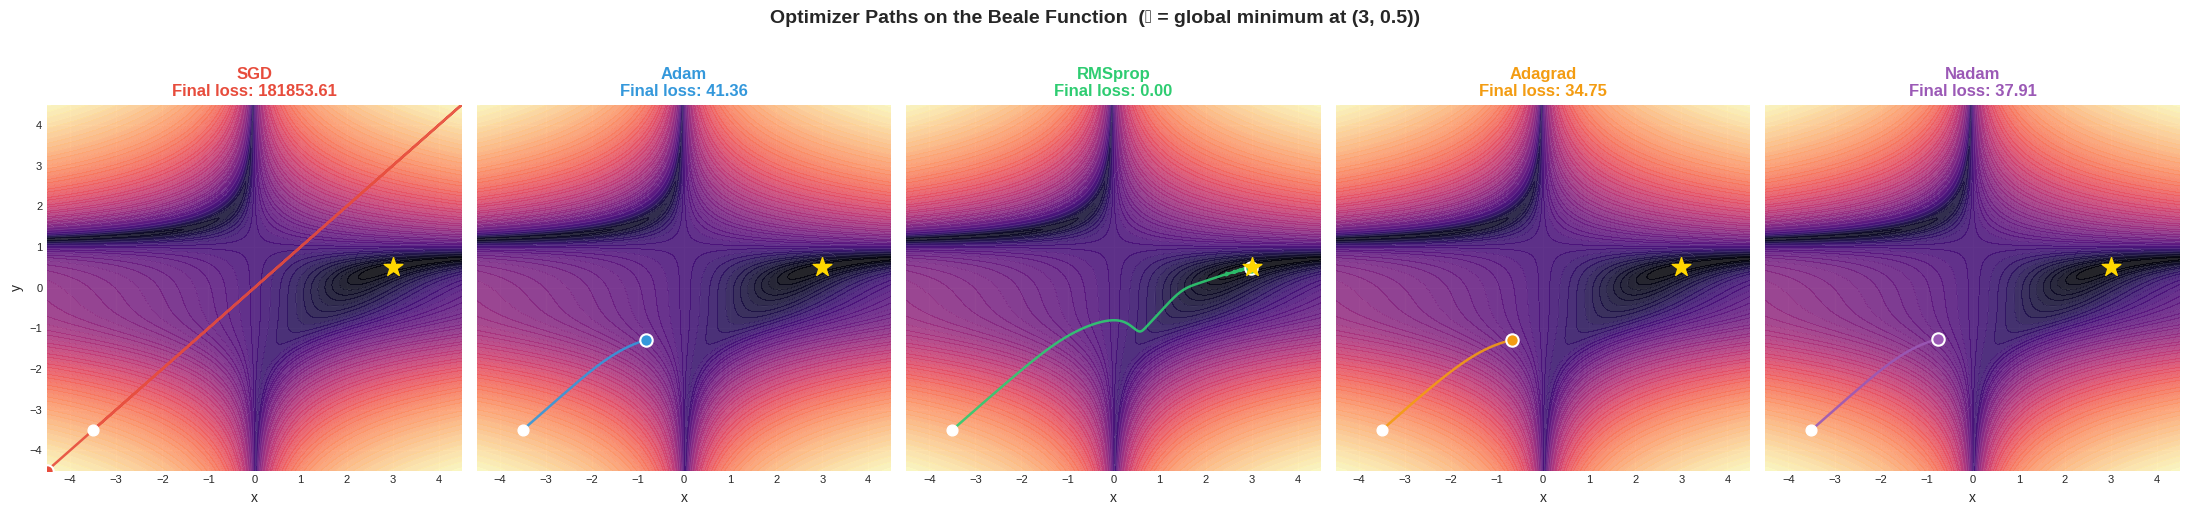

✅ Beale function visualization saved.


In [ ]:
# ── 2D Landscape: Beale Function ──────────────────────────────────────────────
def beale(x, y):
    return ((1.5 - x + x*y)**2 +
            (2.25 - x + x*y**2)**2 +
            (2.625 - x + x*y**3)**2)

def beale_grad(x, y):
    """Analytical gradients of Beale function."""
    a = 1.5  - x + x*y;   b = 2.25 - x + x*y**2;  c = 2.625 - x + x*y**3
    dx = 2*a*(-1+y) + 2*b*(-1+y**2) + 2*c*(-1+y**3)
    dy = 2*a*(x)    + 2*b*(2*x*y)   + 2*c*(3*x*y**2)
    return np.array([dx, dy])

def run_optimizer_2d(opt_name, start=(-3.5, -3.5), lr=0.01, steps=500):
    x, y = list(start)
    path = [(x, y)]
    # Optimizer state
    m = np.zeros(2); v = np.zeros(2); G = np.zeros(2)
    b1, b2, rho, eps = 0.9, 0.999, 0.9, 1e-8
    for t in range(1, steps+1):
        g = beale_grad(x, y)
        if opt_name == 'SGD':
            m = b1*m + g
            upd = lr * m
        elif opt_name == 'Adagrad':
            G += g**2
            upd = lr / (np.sqrt(G) + eps) * g
        elif opt_name == 'RMSprop':
            v = rho*v + (1-rho)*g**2
            upd = lr / (np.sqrt(v) + eps) * g
        elif opt_name == 'Adam':
            m = b1*m + (1-b1)*g
            v = b2*v + (1-b2)*g**2
            mh = m/(1-b1**t); vh = v/(1-b2**t)
            upd = lr * mh / (np.sqrt(vh) + eps)
        elif opt_name == 'Nadam':
            m = b1*m + (1-b1)*g
            v = b2*v + (1-b2)*g**2
            mh = m/(1-b1**t); vh = v/(1-b2**t)
            nesterov = b1*mh + (1-b1)/(1-b1**t)*g
            upd = lr * nesterov / (np.sqrt(vh) + eps)
        x -= upd[0]; y -= upd[1]
        # Clamp to plot range
        x = np.clip(x, -4.5, 4.5); y = np.clip(y, -4.5, 4.5)
        path.append((x, y))
    return np.array(path)

# Grid
xr = np.linspace(-4.5, 4.5, 400)
yr = np.linspace(-4.5, 4.5, 400)
X, Y = np.meshgrid(xr, yr)
Z = np.log1p(beale(X, Y))  # log scale for visibility

fig, axes = plt.subplots(1, 5, figsize=(22, 5), sharey=True)
fig.suptitle('Optimizer Paths on the Beale Function  (★ = global minimum at (3, 0.5))',
             fontsize=14, fontweight='bold', y=1.02)

LR_MAP = {'SGD': 0.005, 'Adagrad': 0.5, 'RMSprop': 0.02, 'Adam': 0.05, 'Nadam': 0.05}

for ax, name in zip(axes, OPTIMIZERS):
    path = run_optimizer_2d(name, lr=LR_MAP[name])
    ax.contourf(X, Y, Z, levels=60, cmap='magma', alpha=0.85)
    ax.contour(X, Y, Z, levels=20, colors='white', alpha=0.15, linewidths=0.5)
    ax.plot(path[:,0], path[:,1], color=PALETTE[name], lw=1.8, alpha=0.9, label=name)
    ax.scatter(*path[0], color='white', s=60, zorder=5)
    ax.scatter(*path[-1], color=PALETTE[name], s=80, edgecolors='white', linewidth=1.5, zorder=5)
    ax.scatter(3, 0.5, marker='*', color='gold', s=200, zorder=6, label='Global min')
    final_loss = beale(*path[-1])
    ax.set_title(f'{name}\nFinal loss: {final_loss:.2f}', color=PALETTE[name], fontweight='bold')
    ax.set_xlabel('x'); ax.set_xlim(-4.5, 4.5); ax.set_ylim(-4.5, 4.5)
    ax.tick_params(labelsize=8)

axes[0].set_ylabel('y')
plt.tight_layout()
plt.savefig('beale_paths.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ Beale function visualization saved.')

## 4. Benchmark 1 — MNIST Classification (MLP)

In [ ]:
# ── Load & Preprocess MNIST ───────────────────────────────────────────────────
(x_train, y_train), (x_test, y_test) = mnist.load_data()

x_train = x_train.reshape(-1, 784).astype('float32') / 255.0
x_test  = x_test.reshape(-1, 784).astype('float32') / 255.0
y_train = to_categorical(y_train, 10)
y_test  = to_categorical(y_test,  10)

# Use a subset for faster demo (remove [:10000] to use full dataset)
x_train_s, y_train_s = x_train[:10000], y_train[:10000]

print(f'Train: {x_train_s.shape}  Test: {x_test.shape}')

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Train: (10000, 784)  Test: (10000, 784)


In [ ]:
# ── MLP Factory ───────────────────────────────────────────────────────────────
def build_mlp(optimizer):
    model = models.Sequential([
        layers.Input(shape=(784,)),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(128, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.2),
        layers.Dense(64,  activation='relu'),
        layers.Dense(10,  activation='softmax')
    ])
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

def get_optimizer(name, lr=None):
    cfg = {
        'SGD':     keras.optimizers.SGD(learning_rate=lr or 0.01, momentum=0.9, nesterov=False),
        'Adam':    keras.optimizers.Adam(learning_rate=lr or 0.001),
        'RMSprop': keras.optimizers.RMSprop(learning_rate=lr or 0.001),
        'Adagrad': keras.optimizers.Adagrad(learning_rate=lr or 0.01),
        'Nadam':   keras.optimizers.Nadam(learning_rate=lr or 0.001),
    }
    return cfg[name]

# ── Train All Optimizers on MNIST ─────────────────────────────────────────────
EPOCHS   = 30
BATCH    = 128
mnist_histories = {}
mnist_times     = {}

for name in OPTIMIZERS:
    print(f'\n🔄 Training {name} on MNIST...')
    tf.random.set_seed(SEED)
    model = build_mlp(get_optimizer(name))
    cb = callbacks.EarlyStopping(monitor='val_accuracy', patience=7,
                                  restore_best_weights=True, verbose=0)
    t0 = time.time()
    hist = model.fit(
        x_train_s, y_train_s,
        validation_split=0.15,
        epochs=EPOCHS, batch_size=BATCH,
        callbacks=[cb], verbose=0
    )
    elapsed = time.time() - t0
    _, test_acc = model.evaluate(x_test, y_test, verbose=0)
    mnist_histories[name] = hist.history
    mnist_histories[name]['test_accuracy'] = test_acc
    mnist_times[name] = elapsed
    n_epochs = len(hist.history['loss'])
    print(f'   ✅ {name:8s} | Test Acc: {test_acc:.4f} | Epochs: {n_epochs} | Time: {elapsed:.1f}s')


🔄 Training SGD on MNIST...
   ✅ SGD      | Test Acc: 0.9545 | Epochs: 30 | Time: 16.7s

🔄 Training Adam on MNIST...
   ✅ Adam     | Test Acc: 0.9523 | Epochs: 30 | Time: 16.5s

🔄 Training RMSprop on MNIST...
   ✅ RMSprop  | Test Acc: 0.9505 | Epochs: 17 | Time: 11.7s

🔄 Training Adagrad on MNIST...
   ✅ Adagrad  | Test Acc: 0.9473 | Epochs: 30 | Time: 15.0s

🔄 Training Nadam on MNIST...
   ✅ Nadam    | Test Acc: 0.9580 | Epochs: 28 | Time: 16.8s


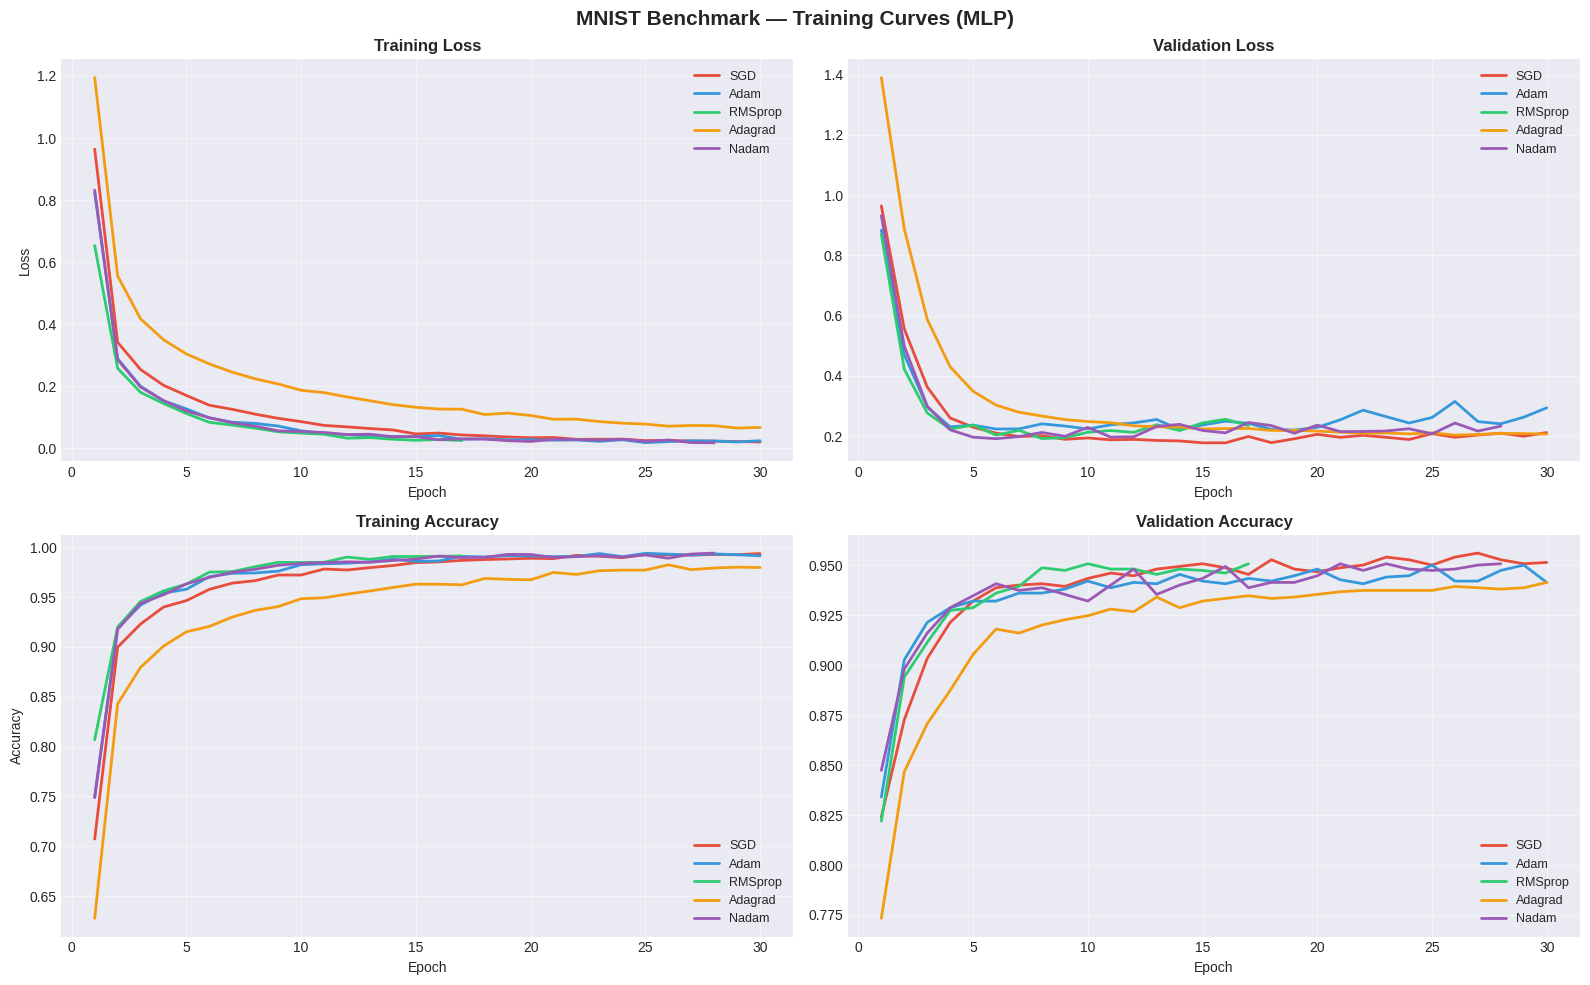


📊 MNIST Results:
Optimizer Test Accuracy Best Val Acc Min Val Loss  Epochs Trained Train Time (s)
    Nadam        0.9580       0.9507       0.1916              28           16.8
      SGD        0.9545       0.9560       0.1779              30           16.7
     Adam        0.9523       0.9500       0.2201              30           16.5
  RMSprop        0.9505       0.9507       0.1921              17           11.7
  Adagrad        0.9473       0.9413       0.2035              30           15.0


In [ ]:
# ── MNIST Training Curves ─────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('MNIST Benchmark — Training Curves (MLP)', fontsize=15, fontweight='bold')

metrics = [
    ('loss',     'val_loss',     'Training Loss',       'Validation Loss'),
    ('accuracy', 'val_accuracy', 'Training Accuracy',   'Validation Accuracy'),
]

for row, (tr_key, val_key, tr_label, val_label) in enumerate(metrics):
    ax_tr  = axes[row][0]
    ax_val = axes[row][1]
    for name in OPTIMIZERS:
        h = mnist_histories[name]
        ep = range(1, len(h[tr_key])+1)
        ax_tr.plot(ep,  h[tr_key],  color=PALETTE[name], lw=2, label=name)
        ax_val.plot(ep, h[val_key], color=PALETTE[name], lw=2, label=name)
    for ax, title in [(ax_tr, tr_label), (ax_val, val_label)]:
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.4)

axes[0][0].set_ylabel('Loss')
axes[1][0].set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig('mnist_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── MNIST Summary Table ───────────────────────────────────────────────────────
rows = []
for name in OPTIMIZERS:
    h = mnist_histories[name]
    rows.append({
        'Optimizer':       name,
        'Test Accuracy':   f"{h['test_accuracy']:.4f}",
        'Best Val Acc':    f"{max(h['val_accuracy']):.4f}",
        'Min Val Loss':    f"{min(h['val_loss']):.4f}",
        'Epochs Trained':  len(h['loss']),
        'Train Time (s)':  f"{mnist_times[name]:.1f}",
    })

df_mnist = pd.DataFrame(rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print('\n📊 MNIST Results:')
print(df_mnist.to_string(index=False))

## 5. Benchmark 2 — CIFAR-10 Classification (CNN)

In [ ]:
# ── Load & Preprocess CIFAR-10 ────────────────────────────────────────────────
(xc_train, yc_train), (xc_test, yc_test) = cifar10.load_data()

xc_train = xc_train.astype('float32') / 255.0
xc_test  = xc_test.astype('float32')  / 255.0

# Per-channel normalization
mean = xc_train.mean(axis=(0,1,2))
std  = xc_train.std(axis=(0,1,2))
xc_train = (xc_train - mean) / std
xc_test  = (xc_test  - mean) / std

yc_train = to_categorical(yc_train, 10)
yc_test  = to_categorical(yc_test,  10)

# Subset for demo speed
xc_tr_s = xc_train[:8000]; yc_tr_s = yc_train[:8000]
print(f'CIFAR-10  Train: {xc_tr_s.shape}  Test: {xc_test.shape}')

Exception: URL fetch failure on https://www.cs.toronto.edu/~kriz/cifar-10-python.tar.gz: 503 -- Service Unavailable

In [ ]:
# ── CNN Factory ───────────────────────────────────────────────────────────────
def build_cnn(optimizer):
    inp = layers.Input(shape=(32, 32, 3))
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(inp)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(32, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.BatchNormalization()(x)
    x = layers.Conv2D(64, 3, padding='same', activation='relu')(x)
    x = layers.MaxPooling2D(2)(x)
    x = layers.Dropout(0.25)(x)

    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.4)(x)
    out = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inp, out)
    model.compile(optimizer=optimizer,
                  loss='categorical_crossentropy',
                  metrics=['accuracy'])
    return model

# ── Train All Optimizers on CIFAR-10 ──────────────────────────────────────────
CIFAR_EPOCHS = 35
cifar_histories = {}
cifar_times     = {}

for name in OPTIMIZERS:
    print(f'\n🔄 Training {name} on CIFAR-10...')
    tf.random.set_seed(SEED)
    model = build_cnn(get_optimizer(name))
    reduce_lr = callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.5,
                                            patience=4, min_lr=1e-6, verbose=0)
    early    = callbacks.EarlyStopping(monitor='val_accuracy', patience=8,
                                       restore_best_weights=True, verbose=0)
    t0 = time.time()
    hist = model.fit(
        xc_tr_s, yc_tr_s,
        validation_split=0.15,
        epochs=CIFAR_EPOCHS, batch_size=64,
        callbacks=[reduce_lr, early], verbose=0
    )
    elapsed = time.time() - t0
    _, test_acc = model.evaluate(xc_test, yc_test, verbose=0)
    cifar_histories[name] = hist.history
    cifar_histories[name]['test_accuracy'] = test_acc
    cifar_times[name] = elapsed
    n_epochs = len(hist.history['loss'])
    print(f'   ✅ {name:8s} | Test Acc: {test_acc:.4f} | Epochs: {n_epochs} | Time: {elapsed:.1f}s')

In [ ]:
# ── CIFAR-10 Training Curves ───────────────────────────────────────────────────
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('CIFAR-10 Benchmark — Training Curves (CNN)', fontsize=15, fontweight='bold')

for row, (tr_key, val_key, tr_label, val_label) in enumerate(metrics):
    ax_tr  = axes[row][0]
    ax_val = axes[row][1]
    for name in OPTIMIZERS:
        h = cifar_histories[name]
        ep = range(1, len(h[tr_key])+1)
        ax_tr.plot(ep,  h[tr_key],  color=PALETTE[name], lw=2, label=name)
        ax_val.plot(ep, h[val_key], color=PALETTE[name], lw=2, label=name)
    for ax, title in [(ax_tr, tr_label), (ax_val, val_label)]:
        ax.set_title(title, fontweight='bold')
        ax.set_xlabel('Epoch')
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.4)

axes[0][0].set_ylabel('Loss')
axes[1][0].set_ylabel('Accuracy')
plt.tight_layout()
plt.savefig('cifar_curves.png', dpi=150, bbox_inches='tight')
plt.show()

# ── CIFAR Summary Table ────────────────────────────────────────────────────────
rows = []
for name in OPTIMIZERS:
    h = cifar_histories[name]
    rows.append({
        'Optimizer':      name,
        'Test Accuracy':  f"{h['test_accuracy']:.4f}",
        'Best Val Acc':   f"{max(h['val_accuracy']):.4f}",
        'Min Val Loss':   f"{min(h['val_loss']):.4f}",
        'Epochs Trained': len(h['loss']),
        'Train Time (s)': f"{cifar_times[name]:.1f}",
    })

df_cifar = pd.DataFrame(rows).sort_values('Test Accuracy', ascending=False).reset_index(drop=True)
print('\n📊 CIFAR-10 Results:')
print(df_cifar.to_string(index=False))

## 6. Learning Rate Sensitivity Analysis

In [ ]:
# ── Test each optimizer across multiple LR values on MNIST (quick version) ────
LR_GRID = [1e-4, 5e-4, 1e-3, 5e-3, 1e-2, 5e-2, 1e-1]
LR_EPOCHS = 10
lr_results = {name: [] for name in OPTIMIZERS}

print('Running LR sensitivity sweep (this may take a few minutes)...')
for name in OPTIMIZERS:
    for lr in LR_GRID:
        tf.random.set_seed(SEED)
        model = build_mlp(get_optimizer(name, lr=lr))
        hist = model.fit(
            x_train_s, y_train_s,
            validation_split=0.15,
            epochs=LR_EPOCHS, batch_size=128,
            verbose=0
        )
        lr_results[name].append(max(hist.history['val_accuracy']))
    print(f'   ✅ {name} done')

# ── Plot ──────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
for name in OPTIMIZERS:
    ax.plot(LR_GRID, lr_results[name], marker='o', lw=2.5,
            color=PALETTE[name], label=name)

ax.set_xscale('log')
ax.set_xlabel('Learning Rate', fontsize=12)
ax.set_ylabel('Best Validation Accuracy', fontsize=12)
ax.set_title('Learning Rate Sensitivity (MNIST, 10 epochs each)', fontsize=13, fontweight='bold')
ax.legend(fontsize=10)
ax.grid(True, which='both', alpha=0.4)
plt.tight_layout()
plt.savefig('lr_sensitivity.png', dpi=150, bbox_inches='tight')
plt.show()
print('✅ LR sensitivity analysis complete.')

## 7. Convergence Speed — Epochs to Target Accuracy

In [ ]:
# ── How many epochs to reach threshold val accuracy? ──────────────────────────
def epochs_to_target(history, key='val_accuracy', target=0.90):
    for i, v in enumerate(history[key]):
        if v >= target:
            return i + 1
    return None  # never reached

TARGETS = [0.80, 0.85, 0.90, 0.92, 0.94]
conv_rows = []
for name in OPTIMIZERS:
    row = {'Optimizer': name}
    for t in TARGETS:
        ep = epochs_to_target(mnist_histories[name], target=t)
        row[f'{int(t*100)}%'] = ep if ep is not None else '—'
    conv_rows.append(row)

df_conv = pd.DataFrame(conv_rows)
print('📊 Epochs to reach target validation accuracy (MNIST MLP):')
print(df_conv.to_string(index=False))

# ── Convergence Speed Bar Chart ────────────────────────────────────────────────
target = 0.90
conv_ep = {}
for name in OPTIMIZERS:
    ep = epochs_to_target(mnist_histories[name], target=target)
    conv_ep[name] = ep if ep is not None else EPOCHS + 5

fig, ax = plt.subplots(figsize=(9, 5))
bars = ax.bar(OPTIMIZERS, [conv_ep[n] for n in OPTIMIZERS],
              color=[PALETTE[n] for n in OPTIMIZERS],
              edgecolor='white', linewidth=1.5)

for bar, name in zip(bars, OPTIMIZERS):
    v = conv_ep[name]
    label = str(v) if v <= EPOCHS else 'N/A'
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            label, ha='center', va='bottom', fontweight='bold', fontsize=11)

ax.set_title(f'Epochs to Reach {int(target*100)}% Validation Accuracy (MNIST)',
             fontsize=13, fontweight='bold')
ax.set_ylabel('Epochs')
ax.set_ylim(0, EPOCHS + 8)
ax.axhline(y=EPOCHS, color='gray', linestyle='--', alpha=0.5, label='Max epochs')
ax.legend()
plt.tight_layout()
plt.savefig('convergence_speed.png', dpi=150, bbox_inches='tight')
plt.show()

## 8. Final Summary Dashboard

In [ ]:
# ── Radar Chart + Heatmap Summary ─────────────────────────────────────────────
def normalize(arr, higher_better=True):
    mn, mx = min(arr), max(arr)
    if mx == mn:
        return [0.5] * len(arr)
    normed = [(v - mn) / (mx - mn) for v in arr]
    if not higher_better:
        normed = [1 - v for v in normed]
    return normed

# Criteria (all normalized 0..1, higher = better)
criteria = ['MNIST\nAccuracy', 'CIFAR\nAccuracy', 'Convergence\nSpeed',
            'LR\nRobustness', 'Time\nEfficiency']
N = len(criteria)

mnist_acc  = [float(mnist_histories[n]['test_accuracy']) for n in OPTIMIZERS]
cifar_acc  = [float(cifar_histories[n]['test_accuracy']) for n in OPTIMIZERS]
conv_speed = [1 / (conv_ep[n] + 1) for n in OPTIMIZERS]  # fewer epochs = faster
lr_robust  = [np.mean(lr_results[n]) for n in OPTIMIZERS]
time_eff   = [1 / (mnist_times[n] + 1) for n in OPTIMIZERS]

scores_raw = [mnist_acc, cifar_acc, conv_speed, lr_robust, time_eff]
scores_norm = [normalize(s) for s in scores_raw]

# Build per-optimizer score vector
opt_scores = {}
for i, name in enumerate(OPTIMIZERS):
    opt_scores[name] = [scores_norm[c][i] for c in range(N)]

# ── Radar Chart ───────────────────────────────────────────────────────────────
angles = np.linspace(0, 2*np.pi, N, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig = plt.figure(figsize=(18, 8))
gs = gridspec.GridSpec(1, 2, width_ratios=[1, 1.3], figure=fig)
ax_radar = fig.add_subplot(gs[0], polar=True)
ax_heat  = fig.add_subplot(gs[1])

ax_radar.set_theta_offset(np.pi / 2)
ax_radar.set_theta_direction(-1)
ax_radar.set_xticks(angles[:-1])
ax_radar.set_xticklabels(criteria, size=9)
ax_radar.set_ylim(0, 1)
ax_radar.set_yticks([0.25, 0.5, 0.75, 1.0])
ax_radar.set_yticklabels(['0.25','0.5','0.75','1.0'], size=7)
ax_radar.set_title('Optimizer Radar Chart\n(normalized scores)', fontweight='bold', pad=20)

for name in OPTIMIZERS:
    vals = opt_scores[name] + opt_scores[name][:1]
    ax_radar.plot(angles, vals, 'o-', lw=2, color=PALETTE[name], label=name)
    ax_radar.fill(angles, vals, alpha=0.08, color=PALETTE[name])

ax_radar.legend(loc='upper right', bbox_to_anchor=(1.3, 1.15), fontsize=9)

# ── Heatmap ───────────────────────────────────────────────────────────────────
heat_data = np.array([opt_scores[n] for n in OPTIMIZERS])
short_criteria = ['MNIST\nAcc', 'CIFAR\nAcc', 'Conv.\nSpeed', 'LR\nRobust', 'Time\nEff.']
df_heat = pd.DataFrame(heat_data, index=OPTIMIZERS, columns=short_criteria)

cmap = LinearSegmentedColormap.from_list('rg', ['#E74C3C', '#F39C12', '#2ECC71'])
sns.heatmap(df_heat, ax=ax_heat, annot=True, fmt='.2f', cmap=cmap,
            linewidths=0.5, linecolor='white',
            cbar_kws={'label': 'Normalized Score (higher = better)'},
            annot_kws={'size': 11, 'weight': 'bold'})
ax_heat.set_title('Performance Heatmap\n(all metrics normalized 0→1)', fontweight='bold')
ax_heat.set_ylabel('')

plt.suptitle('🏆 Optimizer Comparison — Final Dashboard', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('summary_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# ── Overall Score & Ranking ────────────────────────────────────────────────────
overall = {name: np.mean(opt_scores[name]) for name in OPTIMIZERS}
ranked  = sorted(overall.items(), key=lambda x: x[1], reverse=True)

medals = ['🥇', '🥈', '🥉', '4️⃣', '5️⃣']
print('\n' + '='*55)
print('       🏆  FINAL OPTIMIZER RANKING  🏆')
print('='*55)
for rank, (name, score) in enumerate(ranked):
    bar = '█' * int(score * 30)
    print(f'  {medals[rank]}  {name:8s}  {bar:<30}  {score:.3f}')

print('='*55)
print('\n📌 RECOMMENDATIONS BY USE CASE:\n')
recs = [
    ('General purpose / default',  'Adam'),
    ('Maximum convergence speed',  'Nadam'),
    ('RNNs & sequence models',     'RMSprop'),
    ('Sparse data / NLP',          'Adagrad'),
    ('Fine-tuning pretrained',     'SGD + momentum'),
    ('Computer vision (large)',    'SGD + cosine LR decay'),
]
for use_case, opt in recs:
    print(f'  ✅  {use_case:<30}  →  {opt}')

## 9. Key Takeaways

| Optimizer | Strengths | Weaknesses | Best For |
|-----------|-----------|------------|----------|
| **SGD** | Simple, great generalization | Slow, sensitive to LR | Large-scale vision, fine-tuning |
| **Adam** | Fast, robust, self-tuning | Can overfit, high memory | General purpose |
| **RMSprop** | Good for non-stationary loss | No bias correction | RNNs, online learning |
| **Adagrad** | Sparse gradient support | Vanishing learning rate | NLP, sparse features |
| **Nadam** | Fastest convergence | Complex, high memory | Default upgrade from Adam |

### Golden Rules
1. **Start with Adam** — works well out of the box for most tasks.
2. **Switch to SGD + momentum** for final fine-tuning or when generalization matters.
3. **Use Nadam** when you need Adam but want slightly faster convergence.
4. **RMSprop** is the classic choice for RNNs and time-series.
5. **Adagrad** excels when features are sparse (word embeddings, one-hot vectors).

> ⚠️ **Always tune the learning rate!** The default LR that works for one optimizer may fail for another.